In [78]:
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [79]:
#Use yfinance to download stock data for Novo Nordisk (NVO) from 2000 to 2025
novo = yf.Ticker('NVO')
novo_hist = novo.history(start='2000-01-01', end='2025-12-31').drop(columns=['Volume', 'Dividends', 'Stock Splits'])
novo_hist = novo_hist.reset_index()
novo_hist['Date'] = pd.to_datetime(novo_hist['Date'])
# Set the 'Date' column as the index
novo_hist.set_index('Date', inplace=True)
obs = novo_hist.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'}).dropna()
# Resample the data to monthly frequency
obs = obs.reset_index()
obs

C:\Users\asker\AppData\Local\Temp\ipykernel_13108\1191268515.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs = novo_hist.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'}).dropna()


,Date,Open,High,Low,Close
0,2000-01-31 00:00:00-05:00,0.853510,0.940441,0.782384,0.783174
1,2000-02-29 00:00:00-05:00,0.796609,0.926216,0.787126,0.800560
2,2000-03-31 00:00:00-05:00,0.802141,0.930629,0.796609,0.874855
3,2000-04-30 00:00:00-04:00,0.860514,0.956126,0.815894,0.866888
4,2000-05-31 00:00:00-04:00,0.876449,1.097952,0.876449,1.047755
...,...,...,...,...,...
307,2025-08-31 00:00:00-04:00,47.732133,58.340000,44.548012,56.459999
308,2025-09-30 00:00:00-04:00,56.720001,62.320000,52.720001,55.490002
309,2025-10-31 00:00:00-04:00,56.009998,60.900002,48.490002,49.459999
310,2025-11-30 00:00:00-05:00,49.410000,50.430000,43.080002,49.349998


In [84]:
data = obs[:160]
data

,High,Low,Close
0,0.940441,0.782384,0.783174
1,0.926216,0.787126,0.800560
2,0.930629,0.796609,0.874855
3,0.956126,0.815894,0.866888
4,1.097952,0.876449,1.047755
...,...,...,...
155,12.572058,12.244543,12.518367
156,14.370697,12.618079,14.139827
157,14.913741,12.542144,13.422670
158,14.049317,12.552491,12.628343


In [85]:
window = len(obs)-len(data)
window

152

In [86]:
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]
T = data.shape[0]
print(T)

d = window
D = d

train_data = obs.iloc[T-D:T]
print(train_data)

hmm_price = []

temp_T = T
first_time = True

# Sliding window approach to predict future prices
while T < temp_T + d:

    # Train HMM on data from T-D+1 to T
    train_data = obs.iloc[T-D:T]
    train_data = train_data.dropna()

    # Set the random seed
    np.random.seed(123)

    if(first_time):
      first_time = False
      model = hmm.GaussianHMM(n_components=5)
    else:
      old_model= model
      model = hmm.GaussianHMM(n_components=5, init_params="c")
      model.startprob_ = old_model.startprob_
      model.transmat_ = old_model.transmat_
      model.means_ = old_model.means_

    model.fit(train_data)

    # Calculate original likelihood
    original_likelihood = model.score(train_data)

    # Loop to find new likelihood
    t=T
    min_diff = float('inf')
    min_t = T
    min_likelihood = original_likelihood
    while t-D>  0:
        t = t-1

        train_data = obs.iloc[t-D:t]
        new_likelihood = model.score(train_data)
        if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

    # Calculate the predicted close price
    close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

    hmm_price.append(close_price)
    T=T+1

# Print the calculated prices
print("HMM Prices: ")
print(hmm_price)

# Plot the predicted and observed prices
close = []
truncated_obs = obs.iloc[T-d:T]

for i in truncated_obs['Close']:
  close.append(i)


160
           Low      Close
8     1.215077   1.415067
9     1.276428   1.354512
10    1.047206   1.226544
11    1.056813   1.133672
12    1.111255   1.279064
..         ...        ...
155  12.244543  12.518367
156  12.618079  14.139827
157  12.542144  13.422670
158  12.552491  12.628343
159  12.608010  13.811418

[152 rows x 2 columns]


c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


HMM Prices: 
[np.float64(15.025772094726562), np.float64(13.076395034790039), np.float64(11.026922225952148), np.float64(13.36336612701416), np.float64(12.875429153442383), np.float64(13.431392669677734), np.float64(12.089585304260254), np.float64(13.50411605834961), np.float64(13.38447093963623), np.float64(12.436765670776367), np.float64(18.984189987182617), np.float64(18.28499412536621), np.float64(19.316524505615234), np.float64(15.281963348388672), np.float64(18.45226287841797), np.float64(18.376588821411133), np.float64(17.643754959106445), np.float64(19.937841415405273), np.float64(17.88273048400879), np.float64(19.356353759765625), np.float64(15.96302604675293), np.float64(16.47679328918457), np.float64(16.438119888305664), np.float64(20.432497024536133), np.float64(22.677614212036133), np.float64(23.543283462524414), np.float64(20.452726364135742), np.float64(25.34342384338379), np.float64(22.774690628051758), np.float64(22.370176315307617), np.float64(20.78847885131836), np.f

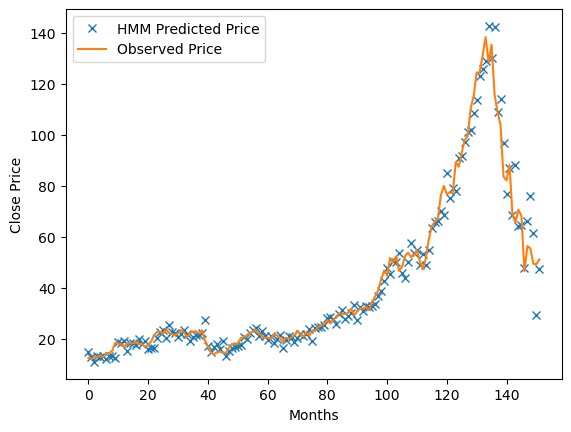

In [89]:

plt.plot(hmm_price, 'x', label = "HMM Predicted Price")
plt.plot(close, label= "Observed Price")
plt.ylabel("Close Price")
plt.xlabel('Months')
plt.legend()
plt.show()

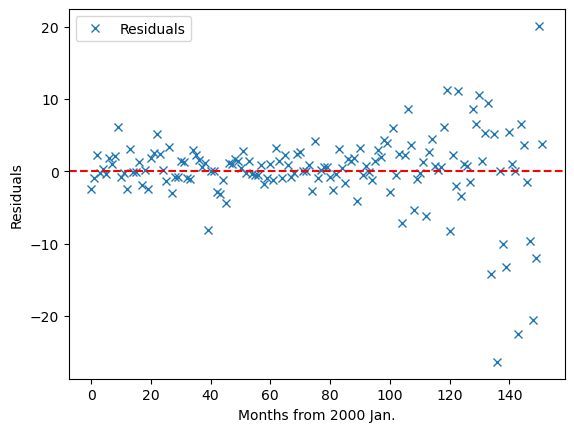

In [88]:
#Calculate residuals: 

residuals = np.array(close) - np.array(hmm_price)
fig, ax = plt.subplots()
x_vals = np.arange(len(residuals))
ax.plot(x_vals, residuals,'x', label='Residuals')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Months from 2000 Jan.')
ax.set_ylabel('Residuals')
ax.legend();
